<a href="https://colab.research.google.com/github/olucasaguiar/projeto-simulacao-opiniao-publica/blob/feature/primeira-tentativa-modelo/simulacao-opiniao-publica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pyreadstat
import pandas as pd
import urllib.parse
import urllib.request

# Original URL for the GitHub blob
raw_github_url = r"https://github.com/olucasaguiar/projeto-simulacao-opiniao-publica/raw/main/docs/04832 PERCEPÇÃO DOS BRASILEIROS ACERCA DA DEMOCRACIA/04832.SAV"

# Convert the blob URL to a raw content URL
raw_github_url_quoted = urllib.parse.quote(raw_github_url, safe=":/")

# Define the local filename
local_filename = "04832.SAV"

# Download the file to the local Colab environment
print(f"Downloading file from: {raw_github_url_quoted}")
urllib.request.urlretrieve(raw_github_url_quoted, local_filename)
print(f"File downloaded to: {local_filename}")

# Load the SPSS file from the local path
df = pd.read_spss(local_filename)
(df.info())

Note: you may need to restart the kernel to use updated packages.
File downloaded to: 04832.SAV
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   SEXO             2000 non-null   category
 1   IDADE            2000 non-null   float64 
 2   FX_ID            2000 non-null   category
 3   ESCOLARIDADE     2000 non-null   category
 4   P1A              2000 non-null   category
 5   P1B              2000 non-null   category
 6   P1C              2000 non-null   category
 7   P2_1             2000 non-null   category
 8   P2_2             1883 non-null   category
 9   P2_3             1791 non-null   category
 10  P3_1             2000 non-null   category
 11  P3_2             818 non-null    category
 12  P3_3             304 non-null    category
 13  P3_4             88 non-null     category
 14  P3_5             55 non-null     category
 15  P3_6

In [2]:
# @title Categorizar escolaridade
escolaridade_map = {
    'Analfabeto': 0,
    'Sabe ler/ escrever, mas não cursou escola': 1,
    'Pré-escola (ou 1º ano)': 2,
    '1ª série': 3,
    '1ª série (ou 2º ano)': 4,
    '2ª série': 5,
    '2ª série (ou 3º ano)': 6,
    '3ª série': 7,
    '3ª série (ou 4º ano)': 8,
    '4ª série (ou 5º ano)': 9,
    '5ª série (ou 6º ano)': 10,
    '6ª série (ou 7º ano)': 11,
    '7ª série (ou 8º ano)': 12,
    '8ª série (ou 9º ano)': 13,
    'Superior incompleto': 14,
    'Superior completo': 15,
}

df['ESCOLARIDADE_GRUPO'] = df['ESCOLARIDADE'].map(escolaridade_map).astype('category')

print(df['ESCOLARIDADE_GRUPO'].value_counts())

ESCOLARIDADE_GRUPO
7     624
15    287
13    207
14    197
9     160
5     107
3      86
10     84
0      56
11     48
12     42
6      36
8      33
4      22
1       9
2       2
Name: count, dtype: int64


In [3]:
# @title Categorizar renda individual e familia
import numpy as np

renda_individual_map = {
    'NÃO RESPONDEU': np.nan,
    'NÃO TEM RENDIMENTO PESSOAL': 0,
    'ATÉ 1': 1,
    'MAIS DE 1 A 2': 2,
    'MAIS DE 10 A 20': 3,
    'MAIS DE 2 A 5': 4,
    'MAIS DE 20': 5,
    'MAIS DE 5 A 10': 6,
}
df['RENDA_INDIVIDUAL'] = df['REND1'].map(renda_individual_map).astype('category')
print(df['RENDA_INDIVIDUAL'].value_counts())

renda_familiar_map = {
    'NÃO RESPONDEU': np.nan,
    'ATÉ 1': 0,
    'MAIS DE 1 A 2': 1,
    'MAIS DE 10 A 20': 2,
    'MAIS DE 2 A 5': 3,
    'MAIS DE 20': 4,
    'MAIS DE 5 A 10': 5,
}
df['RENDA_FAMILIAR'] = df['REND2'].map(renda_familiar_map).astype('category')
print(df['RENDA_FAMILIAR'].value_counts())

RENDA_INDIVIDUAL
1.0    790
2.0    461
4.0    330
0.0    242
6.0     77
3.0     16
5.0      7
Name: count, dtype: int64
RENDA_FAMILIAR
1.0    598
0.0    543
3.0    513
5.0    184
2.0     42
4.0     10
Name: count, dtype: int64


In [4]:
# @title Features selecionadas
scale_features = [
    'IDADE',
    'ESCOLARIDADE_GRUPO',
    'RENDA_INDIVIDUAL',
    'RENDA_FAMILIAR',
]

one_k_features = [
    'SEXO',
    'RACA',
    'RELIGIAO',
    'REGIAO',
]
one_k_categories = [df[i].cat.categories for i in one_k_features]

selected_features = scale_features + one_k_features

targets = ['P2_1']

In [5]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
# from sklearn.preprocessing import Normalizer
# from sklearn.feature_selection import SelectKBest, f_classif

rng = np.random.RandomState(0)

## Preprocessors with Imputation
preprocessor = ColumnTransformer(
    transformers=[
        (
            'scaling',
            Pipeline(
                steps=[
                    (
                        'imputer',
                        SimpleImputer(strategy='median')
                    ),
                    (
                        'quantile',
                        QuantileTransformer(
                            n_quantiles=250,
                            output_distribution='normal',
                            random_state=rng,
                        )
                    )
                ]
            ),
            scale_features
        ),
        (
            'one_k',
            OneHotEncoder(
                categories=one_k_categories,
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            one_k_features
        ),
    ],
    remainder='drop',
)

## Feature Selection
feature_selection = Pipeline(
    steps=[
        # ('norm1', Normalizer(norm='l1')),
        ('threshold', VarianceThreshold(threshold=0)),
        # ('kbest', SelectKBest(f_classif, k=15)),
    ],
)

In [7]:
%pip install xgboost
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split


# Dividir conjunto de [treino:testes]
X_train, X_test, y_train, y_test = train_test_split(
    df[selected_features],
    df[targets].values.ravel(),
    test_size=0.4,
    random_state=rng
)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

models = {
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=rng, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(random_state=rng),
    'XGBoost': XGBClassifier(random_state=rng, objective='multi:softmax')
}

results = {}

print("Iniciando comparação de modelos (Cross-Validation)...\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng)

for name, model in models.items():
    temp_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_processing', feature_selection),
        ('classifier', model)
    ])

    cv_scores = cross_val_score(temp_pipeline, X_train, y_train_encoded, cv=cv, scoring='accuracy')
    results[name] = cv_scores.mean()
    print(f"{name}: Accuracy Média = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

best_model_name = max(results, key=results.get)
print(f"\nMelhor modelo identificado: {best_model_name}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 3.8 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.
Iniciando comparação de modelos (Cross-Validation)...

HistGradientBoosting: Accuracy Média = 0.1508 (+/- 0.0396)
GradientBoosting: Accuracy Média = 0.1675 (+/- 0.0170)
XGBoost: Accuracy Média = 0.1450 (+/- 0.0200)

Melhor modelo identificado: GradientBoosting


In [8]:
# @title Avaliando classificador Random Forest
import numpy as np
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split


rng = np.random.RandomState(0)
rf_parameters = {
    'n_estimators': stats.randint(100, 500),
    'ccp_alpha': stats.loguniform(1e-5, 1e-2),
    'max_depth': stats.randint(10, 30),
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=rng, class_weight='balanced'),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=rng),
    n_iter=20,
    random_state=rng,
    param_distributions=rf_parameters,
    n_jobs=-1,
)
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', feature_selection),
        ('estimator_search', rf_search),
    ],
    verbose=True,
)

# Dividir conjunto de [treino:testes] e ajustar o estimador
X_train, X_test, y_train, y_test = train_test_split(
    df[selected_features],
    df[targets].values.ravel(),
    test_size=0.4,
    random_state=rng
)
rf_pipeline.fit(X_train, y_train)

print('Melhor Score (CV): ', rf_search.best_score_)
print('Melhores Parâmetros: ', rf_search.best_params_)

[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] . (step 2 of 3) Processing feature_selection, total=   0.0s
[Pipeline] .. (step 3 of 3) Processing estimator_search, total=  17.2s
Melhor Score (CV):  0.1725
Melhores Parâmetros:  {'ccp_alpha': np.float64(3.234483629410478e-05), 'max_depth': 26, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 267}


In [9]:
# @title Avaliando classificador Gradient Boosting
import numpy as np
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split


rng = np.random.RandomState(0)
gb_parameters = {
    'n_estimators': stats.randint(100, 500),
    'learning_rate': stats.loguniform(0.01, 0.2),
    'max_depth': stats.randint(3, 10),
    'subsample': [0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=rng),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=rng),
    n_iter=20,
    random_state=rng,
    param_distributions=gb_parameters,
    n_jobs=-1,
)
gb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', feature_selection),
        ('estimator_search', gb_search),
    ],
    verbose=True,
)

# Dividir conjunto de [treino:testes] e ajustar o estimador
X_train, X_test, y_train, y_test = train_test_split(
    df[selected_features],
    df[targets].values.ravel(),
    test_size=0.4,
    random_state=rng
)
gb_pipeline.fit(X_train, y_train)

print('Melhor Score (CV): ', gb_search.best_score_)
print('Melhores Parâmetros: ', gb_search.best_params_)

[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] . (step 2 of 3) Processing feature_selection, total=   0.0s
[Pipeline] .. (step 3 of 3) Processing estimator_search, total= 2.5min
Melhor Score (CV):  0.1825
Melhores Parâmetros:  {'learning_rate': np.float64(0.011971904219908545), 'max_depth': 6, 'max_features': 'log2', 'n_estimators': 354, 'subsample': 0.8}


Note: you may need to restart the kernel to use updated packages.

**Relatório de Métricas**

Random Forest:
                                                                               precision    recall  f1-score   support

                                         Ampliar o uso de energias renováveis       0.25      0.09      0.13        11
                     Ampliar os espaços de participação política da população       0.14      0.05      0.08        19
                 Aumentar os impostos de grandes fortunas (ou dos mais ricos)       0.00      0.00      0.00        15
                                 Combater as mudanças climáticas/desmatamento       0.00      0.00      0.00         4
Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)       0.12      0.12      0.12        93
                                 Defender a igualdade entre homens e mulheres       0.00      0.00      0.00        17
                                             Incentivar a

[]

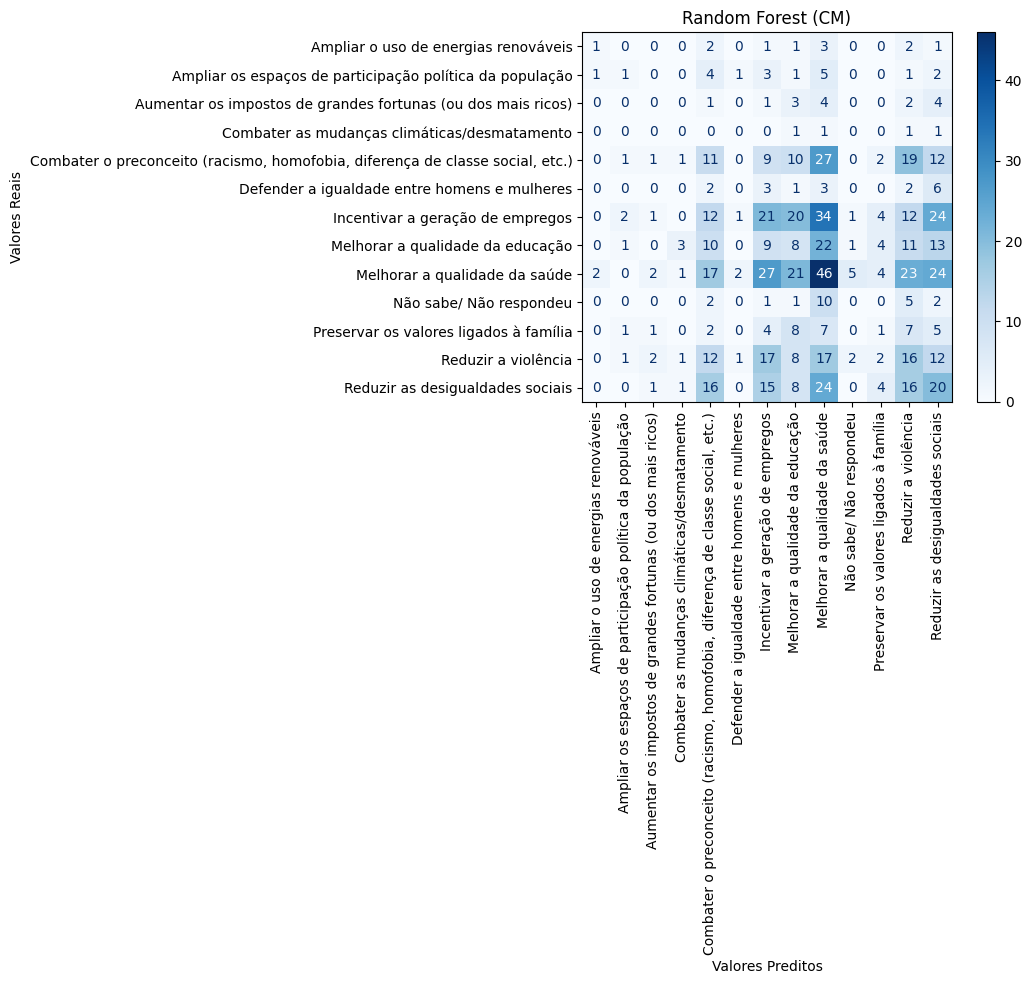

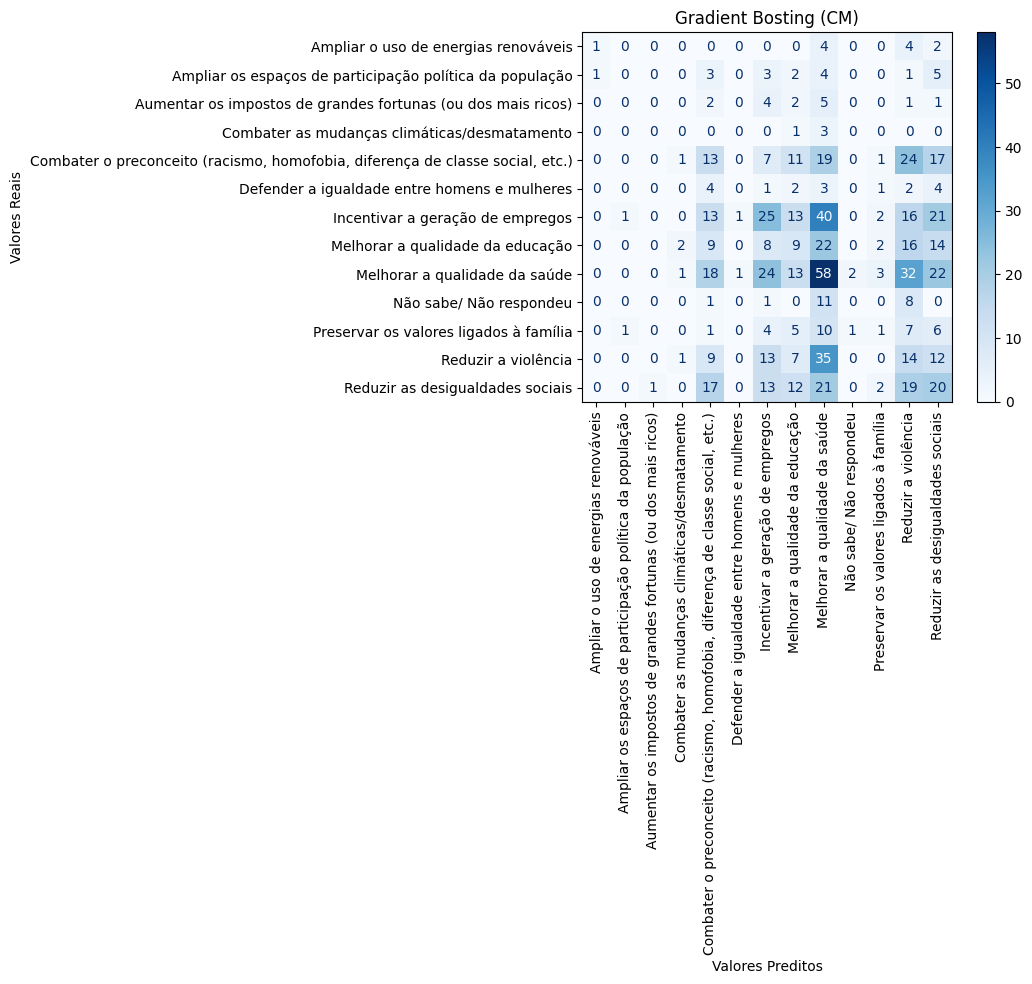

In [10]:
%pip install matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


print('\n**Relatório de Métricas**')
print("\nRandom Forest:")
rf_y_pred = rf_pipeline.predict(X_test)
print(classification_report(y_test, rf_y_pred))
disp = ConfusionMatrixDisplay.from_predictions(y_test, rf_y_pred, cmap='Blues')
disp.ax_.set_title('Random Forest (CM)')
disp.ax_.set_xlabel('Valores Preditos')
disp.ax_.set_ylabel('Valores Reais')
plt.xticks(rotation=90)
plt.plot()

print('\nGradient Bosting:')
gb_y_pred = gb_pipeline.predict(X_test)
print(classification_report(y_test, gb_y_pred))
disp = ConfusionMatrixDisplay.from_predictions(y_test, gb_y_pred, cmap='Blues')
disp.ax_.set_title('Gradient Bosting (CM)')
disp.ax_.set_xlabel('Valores Preditos')
disp.ax_.set_ylabel('Valores Reais')
plt.xticks(rotation=90)
plt.plot()